 2:32 PM
### Seaborn ( https://seaborn.pydata.org/ )
* matplotlib을 기반으로 한 시각화 라이브러리
* 다양한 색상과 차트를 지원
* matplotlib보다 디자인적으로 우위를 가지고 있다

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [8]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = (5,3) # 가로 세로 크기 지정
plt.rcParams['axes.unicode_minus'] = False

In [9]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [10]:
tips['day'].unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

In [11]:
tips.groupby('day').count()

,total_bill,tip,sex,smoker,time,size
day,,,,,,
Thur,62,62,62,62,62,62
Fri,19,19,19,19,19,19
Sat,87,87,87,87,87,87
Sun,76,76,76,76,76,76


In [12]:
tips.groupby('day')['total_bill'].count()

day
Thur    62
Fri     19
Sat     87
Sun     76
Name: total_bill, dtype: int64

<BarContainer object of 4 artists>

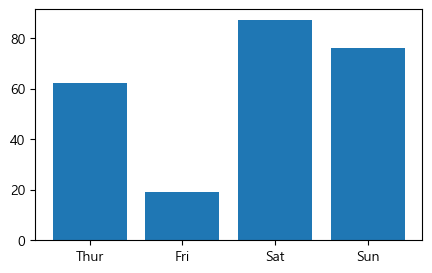

In [15]:
group = tips.groupby('day')['total_bill'].count()
index_x = list(group.index)
count_y = list(group)
plt.bar(index_x, count_y)

<Axes: >

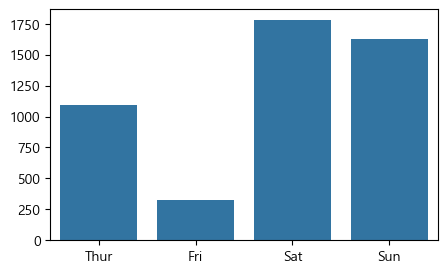

In [17]:
group = tips.groupby('day')['total_bill'].sum()
index_x = list(group.index)
count_y = list(group)

sns.barplot(x=index_x, y=count_y, palette = "Set2")
#https://seaborn.pydata.org/tutorial/color_palettes.html

In [18]:
tips.groupby('day').describe()

total_bill                                                             \
          count       mean       std   min      25%    50%      75%    max   
day                                                                          
Thur       62.0  17.682742  7.886170  7.51  12.4425  16.20  20.1550  43.11   
Fri        19.0  17.151579  8.302660  5.75  12.0950  15.38  21.7500  40.17   
Sat        87.0  20.441379  9.480419  3.07  13.9050  18.24  24.7400  50.81   
Sun        76.0  21.410000  8.832122  7.25  14.9875  19.63  25.5975  48.17   

       tip            ...                 size                                \
     count      mean  ...     75%    max count      mean       std  min  25%   
day                   ...                                                      
Thur  62.0  2.771452  ...  3.3625   6.70  62.0  2.451613  1.066285  1.0  2.0   
Fri   19.0  2.734737  ...  3.3650   4.73  19.0  2.105263  0.567131  1.0  2.0   
Sat   87.0  2.993103  ...  3.3700  10.00  87.0  2.517241  0.819275  1.0  2.0   
Sun   76.0  3.255132  ...  4.0000   6.50  76.0  2.842105  1.007341  2.0  2.0   

                     
      50%  75%  max  
day                  
Thur  2.0  2.0  6.0  
Fri   2.0  2.0  4.0  
Sat   2.0  3.0  5.0  
Sun   2.0  4.0  6.0  

[4 rows x 24 columns]

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: mean, dtype: float64


<Axes: xlabel='day'>

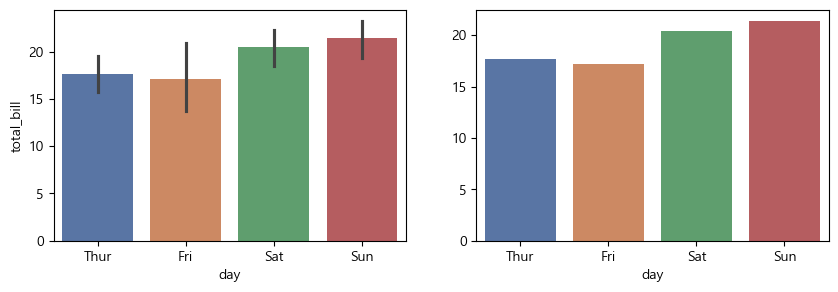

In [25]:
fig, axes = plt.subplots(1,2, figsize=(10,3))
sns.barplot(x='day', y='total_bill', data=tips, palette='deep', ax=axes[0])

data = tips['total_bill'].groupby(tips['day']).describe()['mean']
print(data)
x_data = data.index
y_data = list(data)
sns.barplot(x=x_data, y=y_data, palette='deep', ax=axes[1])

### Seaborn 그래프( https://seaborn.pydata.org/tutorial/function_overview.html )
* 그래프를 그리고자 할때는 속성값이 수치형인지, 카테고리형(범주형)인지를 파악 후 선택하는 것이 좋다

* 수치형
    * relplot : 관계를 나타내고자 할때 사용한다
        - scatterplot : 산포도(x,y를 점으로 표현)
        - lineplot : 선 그래프
    * displot : 분포를 나타내고자 할때 사용한다
* 카테고리형(범주형) 남자, 여자 등 분류가 정해져 있는 데이터
    * catplot : 카테고리형(범주형)을 표현할때 사용하며, 남자, 여자 등 분류가 정해져 있는 데이터 이용할 때 사용한다

In [26]:
tips = sns.load_dataset('tips')
tips.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


### replot

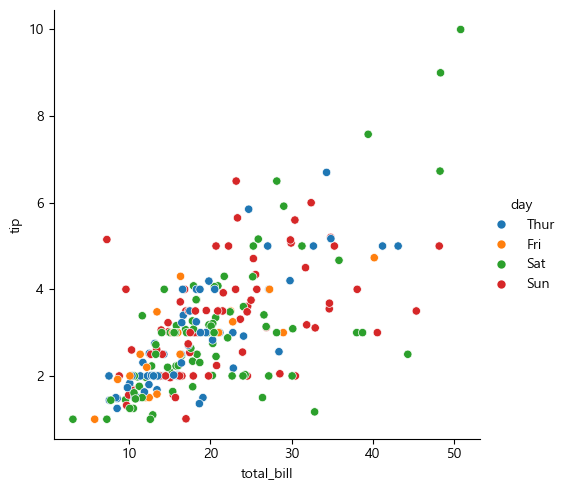

In [29]:
sns.relplot(x='total_bill', y='tip', hue='day', data=tips)

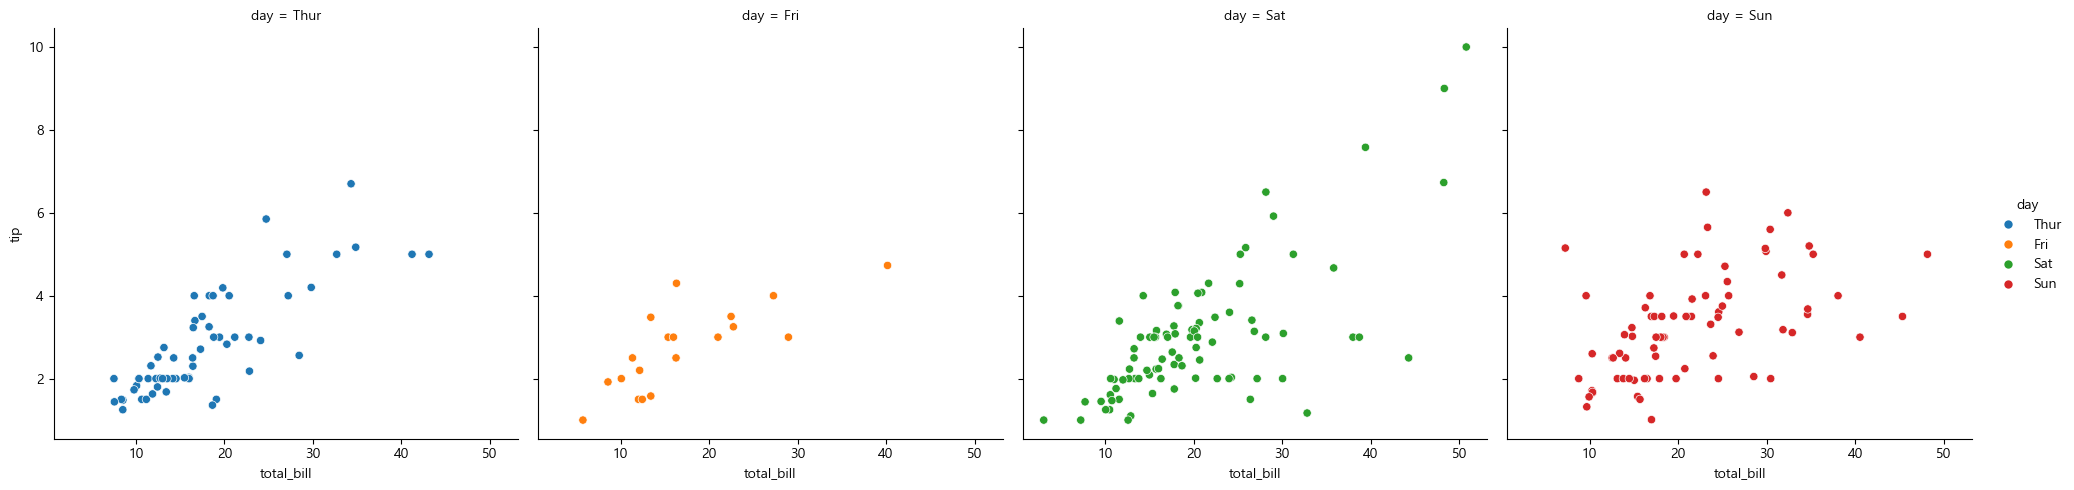

In [30]:
sns.relplot(x='total_bill', y='tip', hue='day', data=tips, col='day')

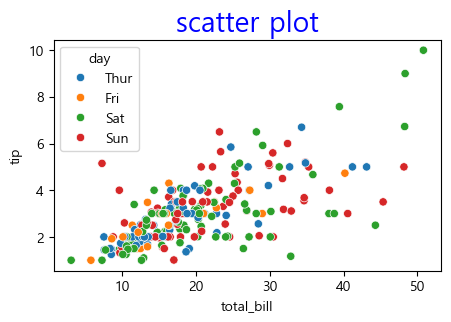

In [32]:
g = sns.scatterplot(x='total_bill', y='tip', hue='day', data=tips)
g.set_title("scatter plot", fontsize=20, color='blue')
plt.show()

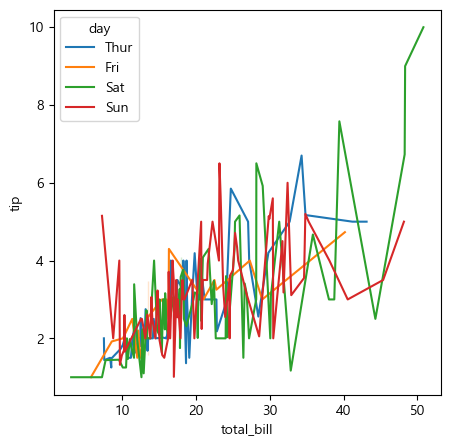

In [33]:
fig, ax = plt.subplots(figsize=(5,5))
sns.lineplot(x='total_bill',y='tip',hue='day',data=tips)
plt.show()

### distplot

In [34]:
titanic = sns.load_dataset('titanic')
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


<Axes: ylabel='Density'>

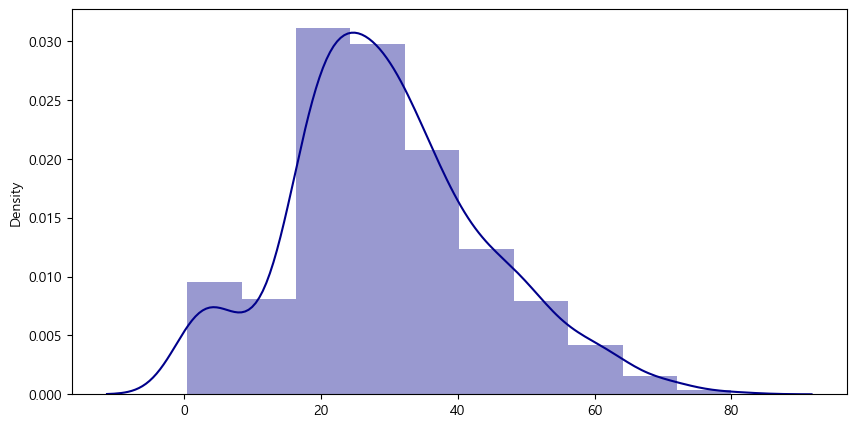

In [36]:
fig, ax = plt.subplots(figsize=(10,5))
sns.distplot(x=titanic['age'], color='darkblue', bins=10)

<Axes: xlabel='age', ylabel='Count'>

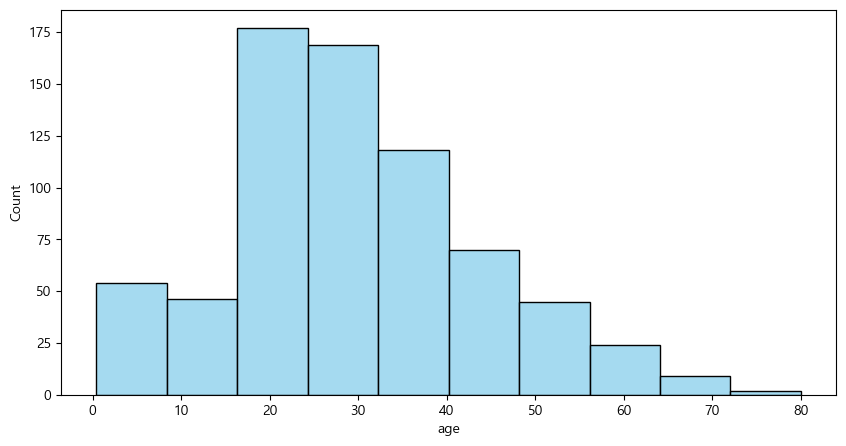

In [37]:
fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(x=titanic['age'], color='skyblue', bins=10)

<Axes: xlabel='day', ylabel='total_bill'>

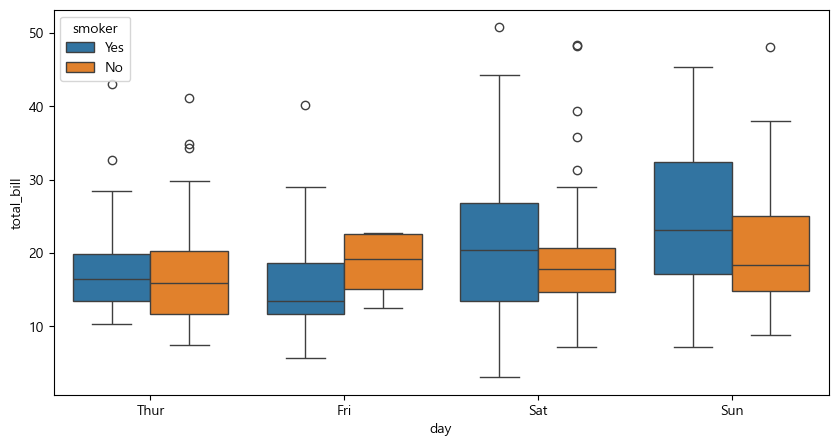

In [38]:
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='day', y='total_bill', hue='smoker', data=tips)

### heatmap

In [39]:
tips.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

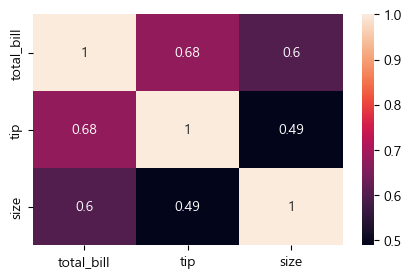

In [40]:
sns.heatmap(tips.corr(numeric_only=True), annot=True)